# Cluster Analysis — Swindon LSOA Typology

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

## 1. Load data (all Swindon LSOAs)

In [2]:
DATA = Path(".")
if not (DATA / "data_swindon_with_commute.csv").exists():
    DATA = Path("cluster_analysis")

swindon = pd.read_csv(DATA / "data_swindon_with_commute.csv")

try:
    import geopandas as gpd
    geo_names = gpd.read_file(DATA / "swindon_lsoa_2021_all137.geojson")[["LSOA21CD", "LSOA21NM"]]
    swindon = swindon.merge(geo_names, on="LSOA21CD", how="left")
except Exception:
    pass

print(f"Reading from: {DATA.resolve()}")
print(f"Swindon LSOAs: {len(swindon)}")
print(swindon[["LSOA21CD", "MSOA21CD"]].head())

Reading from: /Users/bryanlu/Desktop/DS final project/cluster_analysis
Swindon LSOAs: 137
    LSOA21CD   MSOA21CD
0  E01015471  E02006849
1  E01015473  E02003219
2  E01015475  E02003226
3  E01015477  E02003226
4  E01015478  E02003232


## 2. Feature selection

In [3]:
LLM_FEATURES = [
    "log_voa_rv_2023",
    "rv_per_working_age",
    "sme_density",
    "qualification_index",
    "firm_size_diversity",
    "rv_per_employee",
    "sme_qual_interaction",
    "employment_quality",
    "modern_sector_leverage",
    "asset_growth_diversity",
]

COMMUTE_FEATURES = [
    "msoa_out_commute_share",
    "msoa_same_msoa_work_share",
    "msoa_wfh_share",
    "msoa_in_commute_share",
    "msoa_local_worker_share",
]

CLUSTER_FEATURES = LLM_FEATURES + COMMUTE_FEATURES

X = swindon[CLUSTER_FEATURES].copy()
assert X.isna().sum().sum() == 0, "Missing values in clustering features"
print(f"Clustering features: {len(CLUSTER_FEATURES)}")
X.describe().T

Clustering features: 15


,count,mean,std,min,25%,50%,75%,max
log_voa_rv_2023,137.0,13.192562,1.568350,10.348951,11.982023,13.193415,14.290949,16.767356
rv_per_working_age,137.0,1363.532555,2459.496976,30.838411,136.700822,488.167031,1371.742970,18747.546866
sme_density,137.0,192.927224,114.361504,33.250208,105.900151,167.923235,246.264527,616.343490
qualification_index,137.0,7.529042,10.713240,-13.936249,-1.322314,8.112206,17.302173,31.241084
firm_size_diversity,137.0,0.895391,0.020905,0.849481,0.878685,0.904844,0.909617,0.929012
rv_per_employee,137.0,4447.593966,6091.272765,132.813572,1510.568349,3133.519388,5098.520150,55208.601777
sme_qual_interaction,137.0,1838.370262,2622.987045,-3066.836722,-147.530906,1447.187295,2695.730843,16777.359269
employment_quality,137.0,0.209981,0.328141,0.003659,0.045983,0.089959,0.237301,2.396405
modern_sector_leverage,137.0,3.046145,3.925686,-3.484062,-0.322376,2.662037,6.492773,12.708238
asset_growth_diversity,137.0,6.050364,10.251735,-26.084441,1.570892,8.091725,13.215730,40.578075


## 3. Choose k (silhouette + elbow)

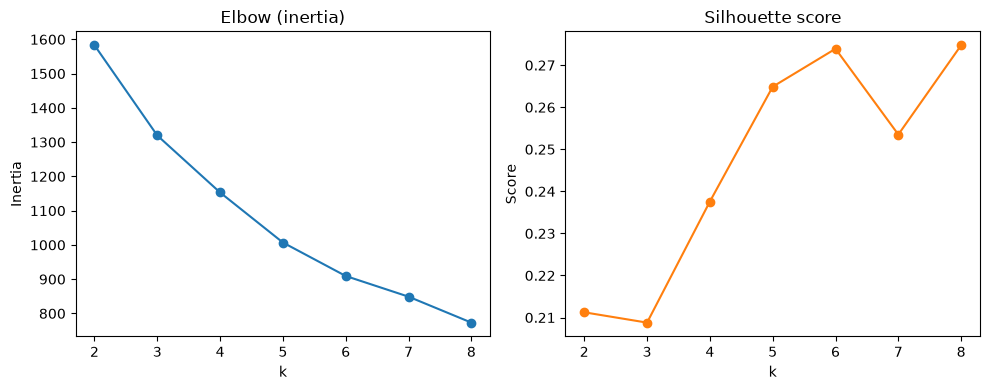

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow (inertia)")

axes[1].plot(list(ks), silhouettes, marker="o", color="C1")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].set_title("Silhouette score")
fig.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]

## 4. Fit k-means & assign clusters

In [5]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
swindon["cluster"] = kmeans.fit_predict(X_scaled)
print("Silhouette (final):", round(silhouette_score(X_scaled, swindon["cluster"]), 3))
swindon["cluster"].value_counts().sort_index()

Silhouette (final): 0.274


cluster
0    17
1    39
2    33
3     5
4    30
5    13
Name: count, dtype: int64

## 5. Cluster profiles (interpretation)



In [6]:
CLUSTER_LABELS = {
    0: "Employment & enterprise hub",
    1: "Deprived low-enterprise residential",
    2: "High-skilled outbound residential",
    3: "High-RV compact workplace",
    4: "Mid SME / mixed residential",
    5: "Moderate-skill local-work residential",
}
CLUSTER_DESCRIPTIONS = {
    0: "Highest mean log GVA; high SME density, employment quality and inbound commute share",
    1: "Largest cluster; lowest SME density, qualifications and mean log GVA; high outbound commute",
    2: "Highest qualification and WFH shares; high outbound commute; mid-low GVA",
    3: "Small n=5 group with extreme RV per working-age; high GVA workplace cores",
    4: "Moderate SME density and mid-high mean log GVA; mixed residential–enterprise profile",
    5: "Mid SME density and qualifications; lower inbound commute than hub clusters",
}

swindon["cluster_name"] = swindon["cluster"].map(CLUSTER_LABELS)
swindon["cluster_description"] = swindon["cluster"].map(CLUSTER_DESCRIPTIONS)

profile_cols = CLUSTER_FEATURES + ["log_total_GVA_2023"]
profiles = swindon.groupby("cluster")[profile_cols].mean().round(3)
profiles

,log_voa_rv_2023,rv_per_working_age,sme_density,qualification_index,firm_size_diversity,rv_per_employee,sme_qual_interaction,employment_quality,modern_sector_leverage,asset_growth_diversity,msoa_out_commute_share,msoa_same_msoa_work_share,msoa_wfh_share,msoa_in_commute_share,msoa_local_worker_share,log_total_GVA_2023
cluster,,,,,,,,,,,,,,,,
0,14.776,3089.825,372.035,16.388,0.911,4077.878,6077.744,0.661,6.034,5.918,0.878,0.122,0.335,0.937,0.063,4.937
1,12.480,381.423,92.574,-3.049,0.873,5391.251,-165.834,0.075,-0.680,6.855,0.965,0.035,0.216,0.872,0.128,2.662
2,12.349,413.716,149.398,18.549,0.890,2584.531,2866.618,0.087,7.528,7.693,0.965,0.035,0.353,0.906,0.094,2.876
3,16.406,10542.996,294.419,7.560,0.908,16560.267,2079.893,0.473,2.158,-5.984,0.922,0.078,0.227,0.928,0.072,4.378
4,13.369,1152.466,226.461,2.686,0.914,2416.915,557.467,0.242,1.000,5.270,0.896,0.104,0.236,0.931,0.069,3.871
5,13.758,1419.989,253.845,10.870,0.908,6856.876,2560.057,0.164,4.003,6.071,0.871,0.129,0.286,0.810,0.190,3.003


## 6. GVA comparison (post-hoc)

In [7]:
gva_summary = swindon.groupby("cluster").agg(
    n=("LSOA21CD", "count"),
    mean_log_gva=("log_total_GVA_2023", "mean"),
    median_log_gva=("log_total_GVA_2023", "median"),
)
gva_summary["label"] = gva_summary.index.map(CLUSTER_LABELS)
gva_summary = gva_summary.round(3)
gva_summary

,n,mean_log_gva,median_log_gva,label
cluster,,,,
0,17,4.937,4.934,Employment & enterprise hub
1,39,2.662,2.548,Deprived low-enterprise residential
2,33,2.876,2.612,High-skilled outbound residential
3,5,4.378,3.846,High-RV compact workplace
4,30,3.871,3.637,Mid SME / mixed residential
5,13,3.003,2.783,Moderate-skill local-work residential


## 7. Choropleth map (137 LSOAs)

Map rows: 137, missing cluster: 0


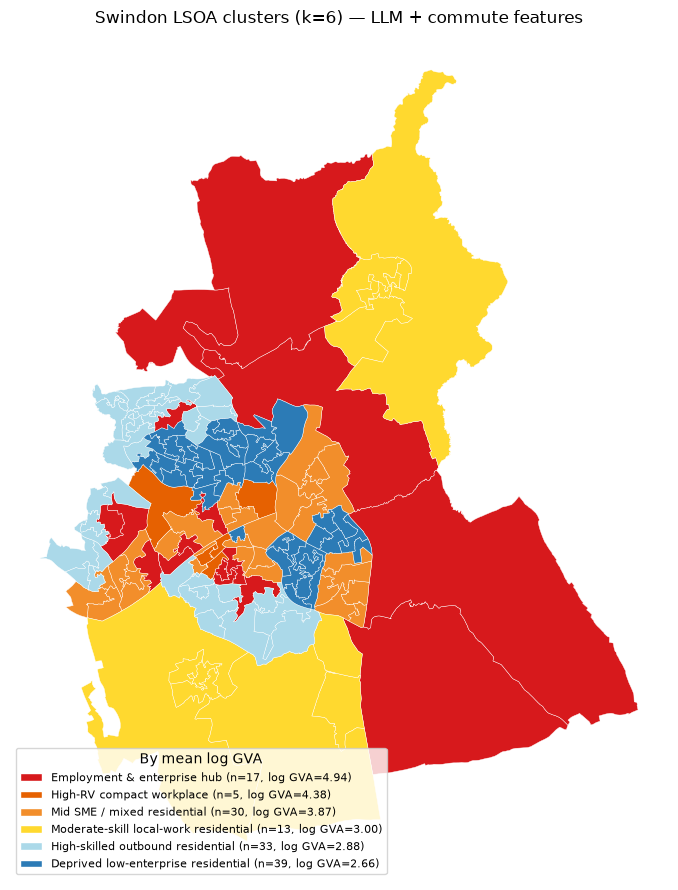

In [8]:
import geopandas as gpd
from matplotlib.patches import Patch

gdf = gpd.read_file(DATA / "swindon_lsoa_2021_all137.geojson")
map_df = gdf.merge(swindon[["LSOA21CD", "cluster", "cluster_name"]], on="LSOA21CD", how="left")
print(f"Map rows: {len(map_df)}, missing cluster: {map_df['cluster'].isna().sum()}")

mean_gva = swindon.groupby("cluster")["log_total_GVA_2023"].mean()
rank_order = list(mean_gva.sort_values(ascending=False).index)
CLUSTER_HEX = {
    0: "#d7191c",
    3: "#e66101",
    4: "#f28e2b",
    5: "#ffd92f",
    2: "#abd9e9",
    1: "#2c7bb6",
}
cluster_to_color = CLUSTER_HEX

fig, ax = plt.subplots(figsize=(9, 9))
for cl in rank_order:
    map_df[map_df["cluster"] == cl].plot(
        ax=ax, color=cluster_to_color[cl], edgecolor="white", linewidth=0.3
    )
ax.set_axis_off()
ax.set_title("Swindon LSOA clusters (k=6) — LLM + commute features")
handles = [
    Patch(
        facecolor=cluster_to_color[cl],
        edgecolor="white",
        label=f"{CLUSTER_LABELS[cl]} (n={int((swindon.cluster==cl).sum())}, log GVA={mean_gva[cl]:.2f})",
    )
    for cl in rank_order
]
ax.legend(handles=handles, title="By mean log GVA", loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(DATA / "swindon_cluster_map.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Export CSVs + Tableau GeoJSON

In [9]:
gva_rank = swindon.groupby("cluster")["log_total_GVA_2023"].mean().sort_values(ascending=False)
rank_map = {cl: i + 1 for i, cl in enumerate(gva_rank.index)}
MAP_COLOUR = {
    0: "Red (highest GVA)",
    1: "Blue (lowest GVA)",
    2: "Light blue",
    3: "Dark orange",
    4: "Orange",
    5: "Yellow",
}
swindon["gva_rank_within_clusters"] = swindon["cluster"].map(rank_map)
swindon["map_colour_label"] = swindon["cluster"].map(MAP_COLOUR)

summary = (
    swindon.groupby("cluster")
    .agg(n_lsoa=("LSOA21CD", "count"), mean_log_gva=("log_total_GVA_2023", "mean"))
    .reset_index()
)
summary["label"] = summary["cluster"].map(CLUSTER_LABELS)
summary["gva_rank"] = summary["cluster"].map(rank_map)
summary["mean_log_gva"] = summary["mean_log_gva"].round(3)
summary = summary[["cluster", "n_lsoa", "label", "mean_log_gva", "gva_rank"]]

tableau_cols = [
    "LSOA21CD", "LSOA21NM", "MSOA21CD", "cluster", "cluster_name", "cluster_description",
    "log_total_GVA_2023", "sme_density", "employment_quality", "qualification_index",
    "rv_per_working_age", "msoa_out_commute_share", "msoa_in_commute_share",
    "msoa_wfh_share", "gva_rank_within_clusters", "map_colour_label",
]

summary.to_csv(DATA / "cluster_summary_table.csv", index=False)
profiles.to_csv(DATA / "cluster_profiles.csv")
gva_summary.to_csv(DATA / "cluster_gva_summary.csv")
swindon[tableau_cols].to_csv(DATA / "swindon_tableau_ready.csv", index=False)
swindon[["LSOA21CD", "LSOA21NM", "cluster", "cluster_name"]].to_csv(
    DATA / "swindon_cluster_labels.csv", index=False
)

join_cols = [
    "LSOA21CD", "cluster", "cluster_name", "cluster_description",
    "log_total_GVA_2023", "sme_density", "employment_quality", "qualification_index",
    "msoa_out_commute_share", "msoa_in_commute_share",
    "gva_rank_within_clusters", "map_colour_label",
]
joined = gdf.merge(swindon[join_cols], on="LSOA21CD", how="left")
joined.to_file(DATA / "swindon_clusters_for_tableau.geojson", driver="GeoJSON")

print("Wrote:")
print("  cluster_summary_table.csv")
print("  cluster_profiles.csv")
print("  cluster_gva_summary.csv")
print("  swindon_tableau_ready.csv")
print("  swindon_cluster_labels.csv")
print("  swindon_clusters_for_tableau.geojson  <- prefer this in Tableau")
print("  swindon_cluster_map.png")
summary

Wrote:
  cluster_summary_table.csv
  cluster_profiles.csv
  cluster_gva_summary.csv
  swindon_tableau_ready.csv
  swindon_cluster_labels.csv
  swindon_clusters_for_tableau.geojson  <- prefer this in Tableau
  swindon_cluster_map.png


,cluster,n_lsoa,label,mean_log_gva,gva_rank
0,0,17,Employment & enterprise hub,4.937,1
1,1,39,Deprived low-enterprise residential,2.662,6
2,2,33,High-skilled outbound residential,2.876,5
3,3,5,High-RV compact workplace,4.378,2
4,4,30,Mid SME / mixed residential,3.871,3
5,5,13,Moderate-skill local-work residential,3.003,4
